# 01 – Pré-processamento Melhorado (MIQR-CC)

Melhorias face ao baseline:
- CLAHE **leve** (clip_limit=1.5) para não destruir detalhes finos dos ductos
- Redimensionamento para **224×224** em vez de 512×512 (mais rápido, suficiente para EfficientNet-B0)
- Segmentação fluoroscópica mantida da baseline
- Análise da distribuição de classes
- Guarda imagens processadas em estrutura train/val/test

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from pathlib import Path
from tqdm import tqdm
import seaborn as sns
from collections import Counter

# ─── CONFIG ───────────────────────────────────────────────────────────────────
METADATA_PATH = os.environ.get('METADATA_PATH', '../MIQR-CC-Dataset_complete/metadata.csv')
RAW_BASE_DIR  = os.environ.get('RAW_BASE_DIR', '../../dataset')
OUT_DIR       = os.environ.get('OUT_DIR', './dataset_processed')   # onde guardar imagens processadas
TARGET_SIZE   = (224, 224)   # ← reduzido de 512×512
CLAHE_CLIP    = 1.5          # ← leve: não destruir detalhes finos
CLAHE_GRID    = (8, 8)
PHASES        = ['train', 'val', 'test']
# ──────────────────────────────────────────────────────────────────────────────

## 1. Funções de Segmentação (mantidas da baseline)

A baseline detecta linhas verticais (bordas do equipamento fluoroscópico) e corta o segmento válido da imagem. Mantemos esta lógica — é robusta.

In [2]:
def detect_vertical_lines(image, canny1=30, canny2=150, hough_threshold=120,
                           min_line_length=70, max_line_gap=4, angle_threshold_deg=10):
    edges = cv2.Canny(image, canny1, canny2)
    lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi/180, threshold=hough_threshold,
                             minLineLength=min_line_length, maxLineGap=max_line_gap)
    vertical_lines = []
    if lines is not None:
        for l in lines:
            x1, y1, x2, y2 = l[0]
            angle = abs(math.degrees(math.atan2(y2 - y1, x2 - x1)))
            if abs(angle - 90) <= angle_threshold_deg:
                vertical_lines.append(l)
    return edges, vertical_lines


def segment_image_by_vertical_lines(image, lines, min_width=30):
    if not lines:
        return [image]
    lines = sorted(lines, key=lambda x: x[0][0])
    x_positions = [0] + [l[0][0] for l in lines] + [image.shape[1]]
    segments = []
    for i in range(len(x_positions) - 1):
        x_start, x_end = x_positions[i], x_positions[i+1]
        if x_end - x_start >= min_width:
            segments.append(image[:, x_start:x_end])
    return segments if segments else [image]


def is_image_valid(image, min_width=212, black_percentile=90, contrast_threshold=10):
    h, w = image.shape
    if w < min_width:
        return False
    if np.percentile(image, black_percentile) < 1:
        return False
    if image.max() - image.min() < contrast_threshold:
        return False
    return True


def get_best_segment(image):
    """Devolve o maior segmento válido da imagem fluoroscópica."""
    _, lines = detect_vertical_lines(image)
    segments = segment_image_by_vertical_lines(image, lines)
    valid = [s for s in segments if is_image_valid(s)]
    if not valid:
        return image   # fallback: imagem original
    return max(valid, key=lambda s: s.shape[1])  # maior em largura

## 2. Pipeline de Pré-processamento Melhorado

**Diferenças face à baseline:**
- CLAHE com `clip_limit=1.5` (baseline não usa CLAHE — adicionamos aqui de forma conservadora)
- Resize para 224×224 depois da segmentação (não antes)
- Normalização guardada como PNG uint8 (0–255) — a normalização float fica para o DataLoader

In [3]:
clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_GRID)

def preprocess_image(img_path: str) -> np.ndarray | None:
    """
    Pipeline completo:
    1. Leitura em grayscale
    2. Segmentação (remove bordas do equipamento)
    3. CLAHE leve (realça contraste sem destruir detalhes)
    4. Resize 224×224
    Devolve array uint8 [0,255] ou None se falhar.
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    # 1. Segmentação
    img = get_best_segment(img)

    # 2. CLAHE leve
    img = clahe.apply(img)

    # 3. Resize
    img = cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_LINEAR)

    return img


# ─── Visualização rápida ──────────────────────────────────────────────────────
def plot_preprocessing_comparison(img_path: str):
    raw = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if raw is None:
        print(f'Não foi possível abrir: {img_path}')
        return

    seg = get_best_segment(raw)
    clahe_img = clahe.apply(seg)
    final = cv2.resize(clahe_img, TARGET_SIZE)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, im, title in zip(axes,
                              [raw, seg, clahe_img, final],
                              ['Original', 'Após Segmentação', 'CLAHE leve', f'Resize {TARGET_SIZE}']):
        ax.imshow(im, cmap='gray')
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## 3. Processar e Guardar o Dataset

Itera sobre a estrutura `train/val/test` existente e grava as imagens processadas em `OUT_DIR`.

In [4]:
def process_and_save_dataset(raw_base: str, out_base: str, phases=PHASES):
    stats = {}
    for phase in phases:
        phase_dir = os.path.join(raw_base, phase)
        if not os.path.isdir(phase_dir):
            print(f'[AVISO] Directório não encontrado: {phase_dir}')
            continue

        class_names = sorted([d for d in os.listdir(phase_dir)
                               if os.path.isdir(os.path.join(phase_dir, d))])
        phase_stats = {}

        for cls in class_names:
            src_dir = os.path.join(raw_base, phase, cls)
            dst_dir = os.path.join(out_base, phase, cls)
            os.makedirs(dst_dir, exist_ok=True)

            valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
            files = [f for f in os.listdir(src_dir) if f.lower().endswith(valid_exts)]

            ok, fail = 0, 0
            for fname in tqdm(files, desc=f'{phase}/{cls}'):
                src = os.path.join(src_dir, fname)
                dst = os.path.join(dst_dir, Path(fname).stem + '.png')
                processed = preprocess_image(src)
                if processed is not None:
                    cv2.imwrite(dst, processed)
                    ok += 1
                else:
                    fail += 1

            phase_stats[cls] = {'ok': ok, 'fail': fail}
            print(f'  {phase}/{cls}: {ok} ok, {fail} falhou')

        stats[phase] = phase_stats
    return stats


stats = process_and_save_dataset(RAW_BASE_DIR, OUT_DIR)
print('\n✅ Dataset processado em:', OUT_DIR)

train/Biliary_Leaks: 100%|██████████| 110/110 [00:01<00:00, 90.35it/s]


  train/Biliary_Leaks: 110 ok, 0 falhou


train/Lithiasis: 100%|██████████| 505/505 [00:04<00:00, 114.49it/s]


  train/Lithiasis: 505 ok, 0 falhou


train/Normal: 100%|██████████| 197/197 [00:01<00:00, 112.32it/s]


...

  test/Lithiasis: 123 ok, 0 falhou


test/Normal: 100%|██████████| 43/43 [00:00<00:00, 100.75it/s]


  test/Normal: 43 ok, 0 falhou


test/Stricture: 100%|██████████| 84/84 [00:00<00:00, 119.14it/s]

  test/Stricture: 84 ok, 0 falhou

✅ Dataset processado em: ./dataset_processed


## 4. Análise Exploratória — Distribuição de Classes

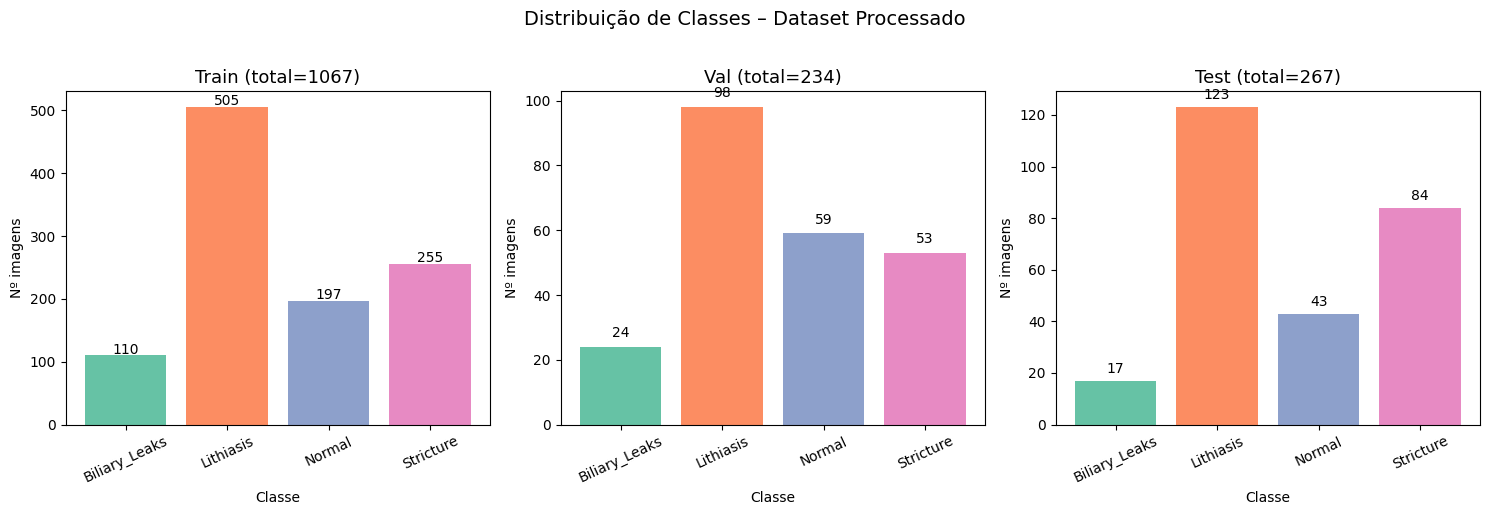


=== Imbalance Ratio (train) ===
  Biliary_Leaks       :  110 imagens  (ratio vs Lithiasis: 4.59x)
  Lithiasis           :  505 imagens  (ratio vs Lithiasis: 1.00x)
  Normal              :  197 imagens  (ratio vs Lithiasis: 2.56x)
  Stricture           :  255 imagens  (ratio vs Lithiasis: 1.98x)


In [5]:
def plot_class_distribution(base_dir: str, phases=PHASES):
    fig, axes = plt.subplots(1, len(phases), figsize=(5 * len(phases), 5))
    if len(phases) == 1:
        axes = [axes]

    all_counts = {}
    for ax, phase in zip(axes, phases):
        phase_dir = os.path.join(base_dir, phase)
        if not os.path.isdir(phase_dir):
            continue
        class_names = sorted([d for d in os.listdir(phase_dir)
                               if os.path.isdir(os.path.join(phase_dir, d))])
        counts = []
        for cls in class_names:
            cls_dir = os.path.join(phase_dir, cls)
            n = len([f for f in os.listdir(cls_dir)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            counts.append(n)

        all_counts[phase] = dict(zip(class_names, counts))

        colors = sns.color_palette('Set2', len(class_names))
        bars = ax.bar(class_names, counts, color=colors)
        ax.set_title(f'{phase.capitalize()} (total={sum(counts)})', fontsize=13)
        ax.set_xlabel('Classe')
        ax.set_ylabel('Nº imagens')
        ax.tick_params(axis='x', rotation=25)
        for bar, count in zip(bars, counts):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                    str(count), ha='center', fontsize=10)

    plt.suptitle('Distribuição de Classes – Dataset Processado', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    return all_counts


counts = plot_class_distribution(OUT_DIR)

# ─── Imbalance ratio ──────────────────────────────────────────────────────────
print('\n=== Imbalance Ratio (train) ===')
train_counts = counts.get('train', {})
if train_counts:
    max_cls = max(train_counts, key=train_counts.get)
    for cls, n in train_counts.items():
        ratio = train_counts[max_cls] / n if n > 0 else float('inf')
        print(f'  {cls:20s}: {n:4d} imagens  (ratio vs {max_cls}: {ratio:.2f}x)')

## 5. Calcular Class Weights para o Treino

Exporta os pesos para usar no notebook de treino.

In [6]:
import json
from sklearn.utils.class_weight import compute_class_weight

train_dir = os.path.join(OUT_DIR, 'train')
class_names = sorted([d for d in os.listdir(train_dir)
                       if os.path.isdir(os.path.join(train_dir, d))])

labels_train = []
for i, cls in enumerate(class_names):
    cls_dir = os.path.join(train_dir, cls)
    n = len([f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    labels_train.extend([i] * n)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(class_names)),
    y=np.array(labels_train)
)

weights_dict = {cls: float(w) for cls, w in zip(class_names, class_weights)}
print('Class weights (balanced):')
for cls, w in weights_dict.items():
    print(f'  {cls:20s}: {w:.4f}')

# Guardar para usar no treino
with open('class_weights.json', 'w') as f:
    json.dump({'class_names': class_names, 'weights': list(class_weights)}, f, indent=2)

print('\n✅ Guardado em class_weights.json')

Class weights (balanced):
  Biliary_Leaks       : 2.4250
  Lithiasis           : 0.5282
  Normal              : 1.3541
  Stricture           : 1.0461

✅ Guardado em class_weights.json


## 6. Visualização de Exemplos por Classe

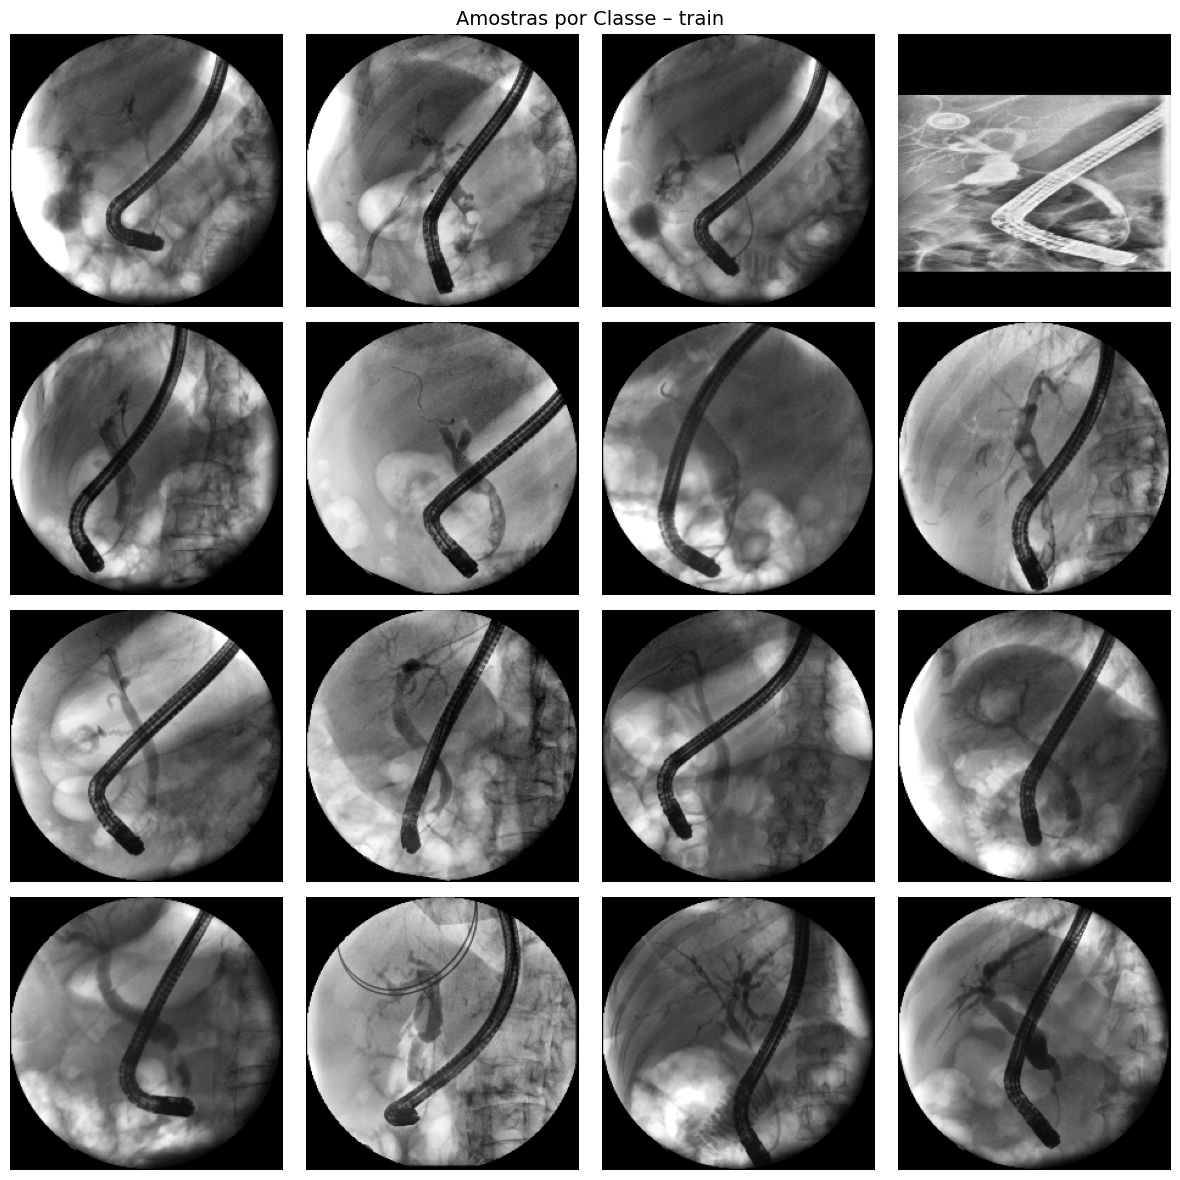

In [7]:
import random

def show_samples_per_class(base_dir: str, phase='train', n_per_class=4):
    phase_dir = os.path.join(base_dir, phase)
    class_names = sorted([d for d in os.listdir(phase_dir)
                           if os.path.isdir(os.path.join(phase_dir, d))])

    fig, axes = plt.subplots(len(class_names), n_per_class,
                              figsize=(3 * n_per_class, 3 * len(class_names)))

    for row, cls in enumerate(class_names):
        cls_dir = os.path.join(phase_dir, cls)
        files = [f for f in os.listdir(cls_dir) if f.lower().endswith('.png')]
        samples = random.sample(files, min(n_per_class, len(files)))

        for col, fname in enumerate(samples):
            img = cv2.imread(os.path.join(cls_dir, fname), cv2.IMREAD_GRAYSCALE)
            axes[row, col].imshow(img, cmap='gray')
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].set_ylabel(cls, fontsize=11, rotation=0, labelpad=80)

    plt.suptitle(f'Amostras por Classe – {phase}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'samples_{phase}.png', dpi=150, bbox_inches='tight')
    plt.show()

show_samples_per_class(OUT_DIR, phase='train', n_per_class=4)